# Sesión 10 — EDA Sistemático y Dashboard U3
**Curso:** Programación para Ciencia de Datos  
**Docente:** Leondry Mayeta Revilla, PhD(c) · leondry.mayeta@upeu.edu.pe · Universidad Peruana Unión  
**Unidad 3:** Visualización y Procesamiento de Información  

**Este notebook es la plantilla del Producto U3.** Al finalizar el taller genera
`Dashboard_U3_[NombreEquipo].ipynb`

> **Insumos requeridos:**
> - CSV referencia.
> - **Preguntas analíticas** formuladas en secciones anteriores.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## Continuidad S09 → S10

Las visualizaciones de S08 (Matplotlib) y S09 (Seaborn) respondieron *qué* ocurre en los datos.
El EDA sistemático de hoy formaliza ese análisis: estadísticos que miden la forma de las
distribuciones, detección cuantitativa de outliers y análisis bivariado exhaustivo que sustenta
cada hipótesis con evidencia.


---
## Sección 0 — Contexto

Define el dataset, la fuente, el problema de decisión y las 3 preguntas analíticas
que guiarán todo el análisis. Esta sección es el marco interpretativo del Dashboard.

---
## Sección 3 — Relaciones

Análisis bivariado exhaustivo: tres tipos de combinación de variables.

| Tipo | Herramientas | Pregunta que responde |
|---|---|---|
| Num × Num | Correlación de Pearson + `regplot` | ¿Cuánto cambia Y cuando X aumenta? |
| Cat × Num | `groupby().agg()` + `boxplot` | ¿Cómo varía la numérica entre categorías? |
| Cat × Cat | `pd.crosstab()` + heatmap de frecuencias | ¿Qué combinaciones son más frecuentes? |

**Observación docente:**
El heatmap de correlación ya estaba en S09. En S10 se extiende con el bivariado Cat×Num
(¿qué región tiene mayor media y mayor variabilidad?) y Cat×Cat (¿qué combinaciones son raras?).
El crosstab revela si algunas celdas están vacías o subrepresentadas, lo que impacta
directamente la representatividad del modelo en U4.

---
## Sección 4 — Comparaciones

barplot con estimator='mean' y errorbar='sd' muestra la media ± desviación estándar
por categoría: responde *"¿cuál categoría rinde más en promedio?"*
countplot ordenado por frecuencia revela **desequilibrios de clase** que impactan
directamente el entrenamiento del modelo en U4.

---
## Sección 5 — Outliers

El método IQR define outliers como valores fuera del rango [Q1 − 1,5×IQR , Q3 + 1,5×IQR].

**Decisión documentada (obligatoria):** cada outlier detectado requiere una decisión explícita:
- **Error de captura** (valor imposible) → eliminar o corregir.
- **Extremo legítimo** (valor inusual pero real) → conservar con nota en la Sección 6.

La decisión impacta directamente la calidad del modelo en U4.


## Bloque II — Tu dataset · trabajo autónomo

A partir de aquí cada equipo trabaja con su propio dataset.
Completa las celdas de las Secciones 0–6 en el orden que aparecen.

In [ ]:
# EQUIPO: cargar su propio CSV


# 1. ¿Cuál es el nombre exacto de tu archivo CSV? → reemplaza [nombre_dataset] en la ruta
# 2. ¿El archivo cargó con una sola columna (df.shape[1] = 1)? → usa sep='\t' (separador TAB)
# 3. ¿Cuántas filas y columnas tiene? → verifica que coincide con lo conocido de S08/S09
# 4. ¿Hay nulos? → anota en qué columnas para anticipar el análisis en S1


RUTA_CSV_EQUIPO = '/content/drive/MyDrive/S06_grupo4_Limpieza.csv'

# Si tu archivo usa separador TAB (ej. marketing_campaign.csv de Kaggle):
# df = pd.read_csv(RUTA_CSV_EQUIPO, sep='\t')
df = pd.read_csv(RUTA_CSV_EQUIPO)

print('Filas:', df.shape[0])
print('Columnas:', df.shape[1])
print('Nulos totales:', df.isnull().sum().sum())
df.head(3)

Filas: 32593
Columnas: 20
Nulos totales: 0


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,module_presentation_length,total_assessments_submitted,average_score,total_weighted_score,total_clicks,unique_days_active
0,aaa,2013j,11391,m,east anglian region,he qualification,90-100%,55<=,0,240,n,pass,-159,268,268,5,82.0,82.4,934,40
1,aaa,2013j,28400,f,scotland,he qualification,20-30%,35-55,0,60,n,pass,-53,268,268,5,66.4,65.4,1435,80
2,aaa,2013j,30268,f,north western region,a level or equivalent,30-40%,35-55,0,60,y,withdrawn,-92,12,268,0,0.0,0.0,281,12


In [ ]:
# Práctica del equipo - Sección 1: exploración inicial del dataset
# Ajusta cols_num_equipo con las variables numéricas más relevantes

# 1. ¿Cuántos registros y variables tiene tu dataset?
#    → identifica dimensión y tipos de columna
# 2. ¿Hay valores ausentes?
#    → en qué variables y qué porcentaje representan
# 3. Selecciona 3-4 variables numéricas clave para tu pregunta analítica principal
# 4. Para cada variable:
#    ¿skewness > 1?
#    → distribución sesgada
#    ¿kurtosis > 0?
#    → colas pesadas
# 5. ¿El CV es bajo (<15%), moderado (15-30%) o alto (>30%)?
#    → interpreta dispersión relativa
# 6. ¿Qué variable presenta mayor variabilidad?
#    → ¿es esperable dado el fenómeno estudiado?

cols_num_equipo = [
    'studied_credits',
    'total_assessments_submitted',
    'average_score',
    'total_weighted_score',
    'total_clicks',
    'unique_days_active'
]

print('1. ¿Cuántos registros y variables tiene tu dataset?')
print('Forma del dataset:', df.shape)
print('Filas:', df.shape[0])
print('Columnas:', df.shape[1])

print('\nTipos de datos:')
display(df.dtypes)

print('\n2. ¿Hay valores ausentes?')
nulos = df.isnull().sum()
porcentaje_nulos = (df.isnull().mean() * 100).round(2)

tabla_nulos = pd.DataFrame({
    'nulos': nulos,
    'porcentaje': porcentaje_nulos
})

display(tabla_nulos[tabla_nulos['nulos'] > 0])

print('\n3. Variables numéricas clave seleccionadas:')
print(cols_num_equipo)

print('\nEstadísticos descriptivos:')
display(df[cols_num_equipo].describe().round(2))

print('\n4. Skewness / Asimetría:')
skew_equipo = df[cols_num_equipo].skew().round(3)
display(skew_equipo)

print('\n4. Kurtosis / Curtosis:')
kurt_equipo = df[cols_num_equipo].kurt().round(3)
display(kurt_equipo)

print('\n5. Coeficiente de variación CV (%):')
cv_equipo = (
    df[cols_num_equipo].std() / df[cols_num_equipo].mean() * 100
).round(1)

display(cv_equipo)

print('\n6. Variable con mayor variabilidad relativa:')
variable_mayor_cv = cv_equipo.idxmax()
valor_mayor_cv = cv_equipo.max()

print(f'La variable con mayor CV es {variable_mayor_cv}, con {valor_mayor_cv}%.')

1. ¿Cuántos registros y variables tiene tu dataset?
Forma del dataset: (32593, 20)
Filas: 32593
Columnas: 20

Tipos de datos:


,0
code_module,object
code_presentation,object
id_student,int64
gender,object
region,object
highest_education,object
imd_band,object
age_band,object
num_of_prev_attempts,int64
studied_credits,int64



2. ¿Hay valores ausentes?


,nulos,porcentaje



3. Variables numéricas clave seleccionadas:
['studied_credits', 'total_assessments_submitted', 'average_score', 'total_weighted_score', 'total_clicks', 'unique_days_active']

Estadísticos descriptivos:


...


4. Kurtosis / Curtosis:


,0
studied_credits,7.738
total_assessments_submitted,-1.287
average_score,-0.732
total_weighted_score,0.025
total_clicks,14.950
unique_days_active,0.946



5. Coeficiente de variación CV (%):


,0
studied_credits,51.5
total_assessments_submitted,81.1
average_score,57.1
total_weighted_score,101.6
total_clicks,139.3
unique_days_active,98.3



6. Variable con mayor variabilidad relativa:
La variable con mayor CV es total_clicks, con 139.3%.


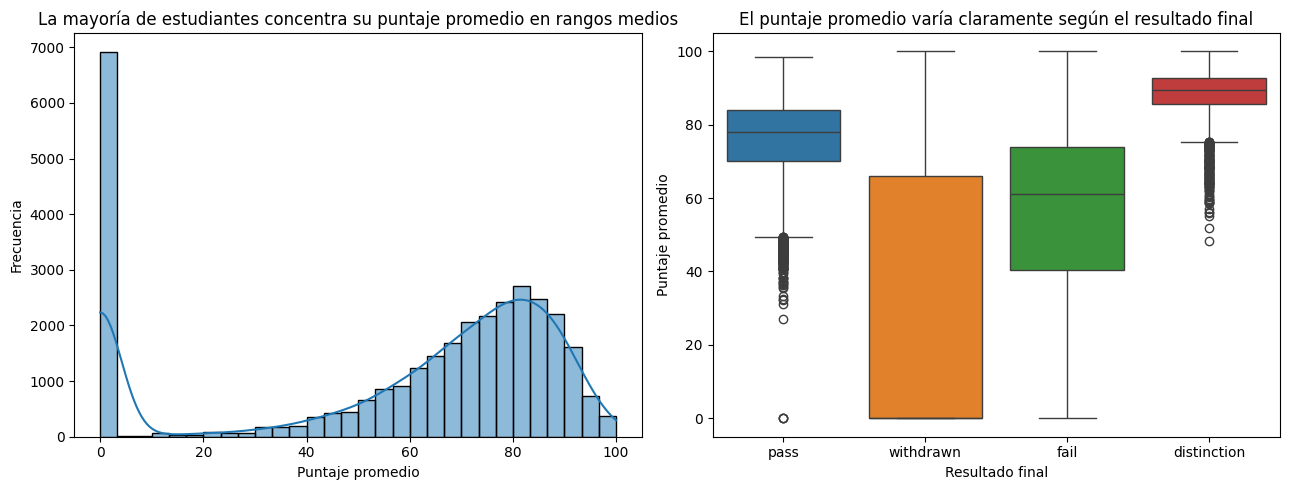

In [ ]:
# Práctica del equipo - Sección 2: distribuciones del dataset

# 1. Variable numérica elegida para el histograma:
#    average_score explica el rendimiento promedio del estudiante.
# 2. Forma esperada:
#    Puede ser unimodal o asimétrica según la concentración de notas.
# 3. Se compara con el skewness calculado en S1.
# 4. Variable categórica elegida:
#    final_result, porque permite segmentar el rendimiento según resultado final.
# 5. Los cuartiles muestran diferencias de rendimiento entre grupos.
# 6. Los valores atípicos se observarán visualmente y luego se analizarán en S5.
# 7. Los títulos describen hallazgos, no solo nombres de variables.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma de average_score
sns.histplot(
    data=df,
    x='average_score',
    bins=30,
    kde=True,
    ax=axes[0]
)

axes[0].set_title('La mayoría de estudiantes concentra su puntaje promedio en rangos medios')
axes[0].set_xlabel('Puntaje promedio')
axes[0].set_ylabel('Frecuencia')

# Boxplot de average_score según resultado final
sns.boxplot(
    data=df,
    x='final_result',
    y='average_score',
    hue='final_result',
    legend=False,
    ax=axes[1]
)

axes[1].set_title('El puntaje promedio varía claramente según el resultado final')
axes[1].set_xlabel('Resultado final')
axes[1].set_ylabel('Puntaje promedio')

plt.tight_layout()
plt.show()

Matriz de correlación de Pearson:


,studied_credits,total_assessments_submitted,average_score,total_weighted_score,total_clicks,unique_days_active
studied_credits,1.000,-0.089,-0.154,-0.041,-0.037,-0.056
total_assessments_submitted,-0.089,1.000,0.679,0.636,0.548,0.646
average_score,-0.154,0.679,1.000,0.595,0.438,0.574
total_weighted_score,-0.041,0.636,0.595,1.000,0.470,0.682
total_clicks,-0.037,0.548,0.438,0.470,1.000,0.837
unique_days_active,-0.056,0.646,0.574,0.682,0.837,1.000


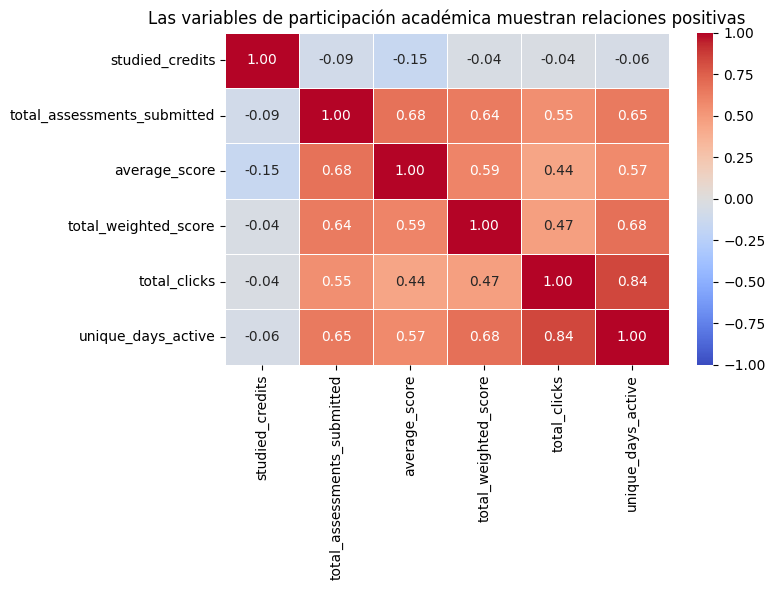

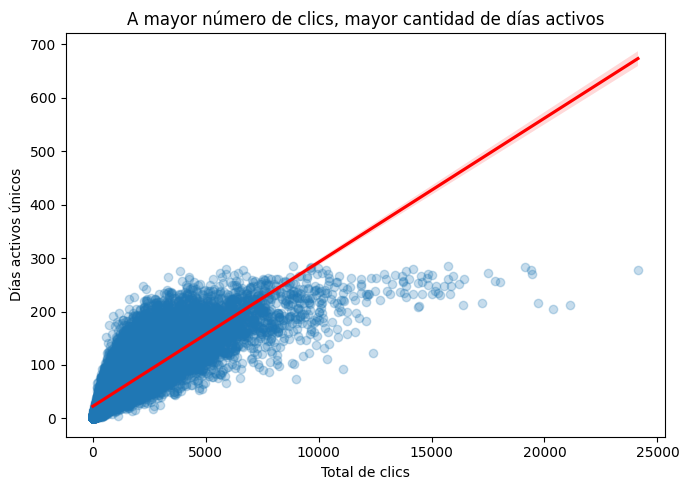

Resumen de puntaje promedio según resultado final:


,mean,std,count
final_result,,,
distinction,88.49,6.65,3024
fail,52.51,29.10,7052
pass,76.16,10.56,12361
withdrawn,29.50,35.09,10156


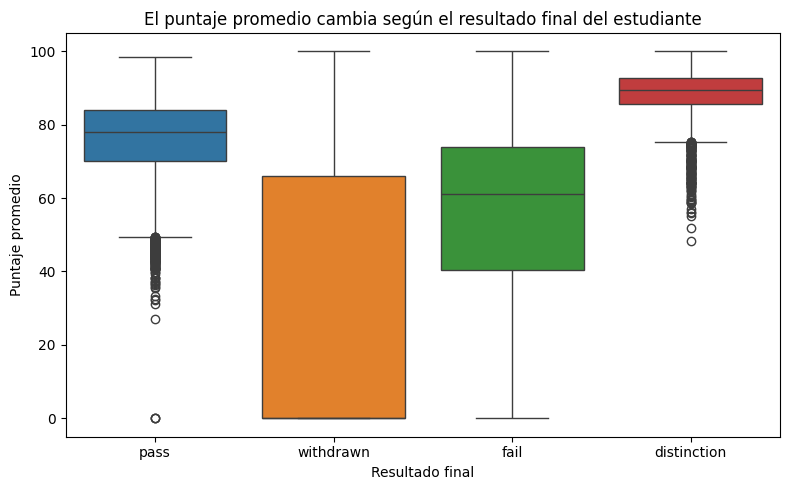

Tabla cruzada: resultado final vs discapacidad


disability,n,y
final_result,,
distinction,2801,223
fail,6340,712
pass,11377,984
withdrawn,8911,1245


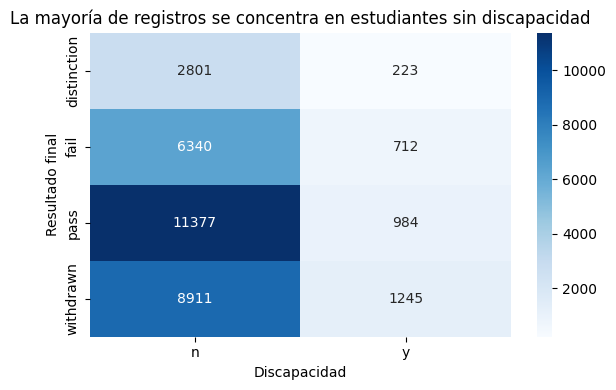

In [ ]:
# Práctica del equipo - Sección 3: análisis bivariado del dataset

# — FLUJO ——————————————————————————————————————————————
# 1. Num×Num → ¿qué par de numéricas tiene mayor correlación? ¿positiva o negativa?
# 2. ¿Esa correlación es coherente con tu pregunta analítica o podría ser un artefacto?
# 3. Num×Num (dispersión) → ¿la relación es lineal o presenta curvatura/dispersión alta?
# 4. Cat×Num → ¿hay diferencia real en la variable numérica entre grupos?
# 5. Cat×Cat → ¿qué dos variables categóricas podrían estar asociadas en tu dataset?
# 6. ¿Alguna relación encontrada cambia o refuerza tu hipótesis inicial?
# — FIN FLUJO ——————————————————————————————————————————

# Columnas numéricas para el heatmap
cols_num_equipo = [
    'studied_credits',
    'total_assessments_submitted',
    'average_score',
    'total_weighted_score',
    'total_clicks',
    'unique_days_active'
]

# =====================================================
# 1. Num x Num: matriz de correlación
# =====================================================

correlacion_eq = df[cols_num_equipo].corr(method='pearson')

print('Matriz de correlación de Pearson:')
display(correlacion_eq.round(3))

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    correlacion_eq,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Las variables de participación académica muestran relaciones positivas')
plt.tight_layout()
plt.show()


# =====================================================
# 2. Num x Num: dispersión con línea de tendencia
# =====================================================

fig, ax = plt.subplots(figsize=(7, 5))

sns.regplot(
    data=df,
    x='total_clicks',
    y='unique_days_active',
    scatter_kws={'alpha': 0.25},
    line_kws={'color': 'red'},
    ax=ax
)

ax.set_title('A mayor número de clics, mayor cantidad de días activos')
ax.set_xlabel('Total de clics')
ax.set_ylabel('Días activos únicos')

plt.tight_layout()
plt.show()


# =====================================================
# 3. Cat x Num: resultado final vs puntaje promedio
# =====================================================

print('Resumen de puntaje promedio según resultado final:')
display(
    df.groupby('final_result')['average_score']
      .agg(['mean', 'std', 'count'])
      .round(2)
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='final_result',
    y='average_score',
    hue='final_result',
    legend=False,
    ax=ax
)

ax.set_title('El puntaje promedio cambia según el resultado final del estudiante')
ax.set_xlabel('Resultado final')
ax.set_ylabel('Puntaje promedio')

plt.tight_layout()
plt.show()


# =====================================================
# 4. Cat x Cat: resultado final vs discapacidad
# =====================================================

tabla_cat = pd.crosstab(
    df['final_result'],
    df['disability']
)

print('Tabla cruzada: resultado final vs discapacidad')
display(tabla_cat)

fig, ax = plt.subplots(figsize=(6, 4))

sns.heatmap(
    tabla_cat,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax
)

ax.set_title('La mayoría de registros se concentra en estudiantes sin discapacidad')
ax.set_xlabel('Discapacidad')
ax.set_ylabel('Resultado final')

plt.tight_layout()
plt.show()

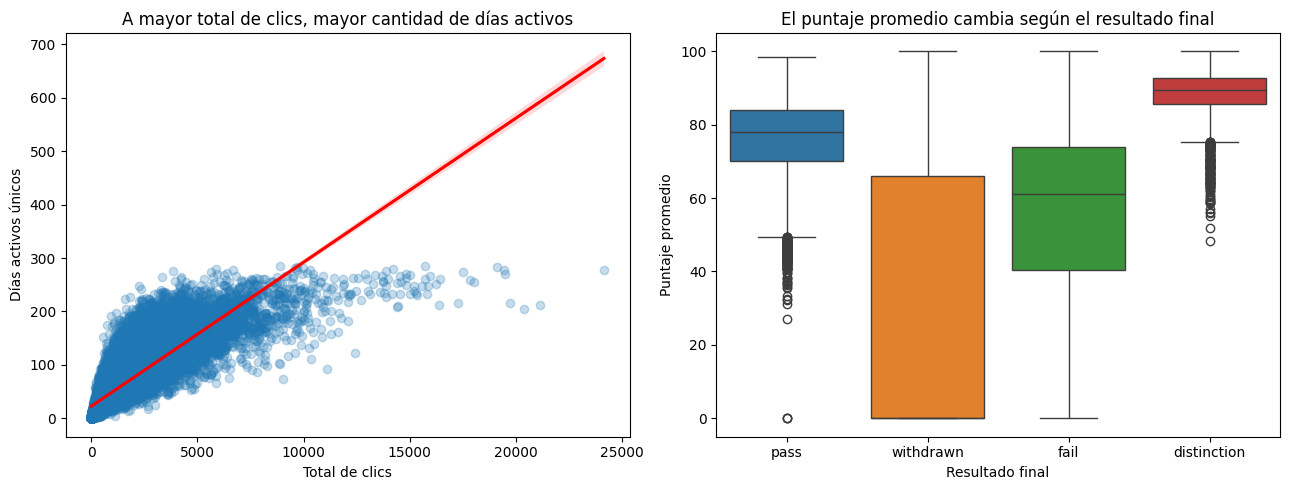

Resumen de puntaje promedio según resultado final:


,mean,median,std,count
final_result,,,,
distinction,88.49,89.42,6.65,3024
fail,52.51,61.00,29.10,7052
pass,76.16,77.86,10.56,12361
withdrawn,29.50,0.00,35.09,10156


In [ ]:
# Eje# Ejercicio guiado - Sección 3: relación NumxNum y CatxNum con tu dataset
# Dataset del equipo: df

# — FLUJO ——————————————————————————————————————————————
# Paso 1 — Del heatmap que construiste en ESPEJADO S3:
#          ¿Qué par de variables numéricas tiene la correlación más alta?
#          → par Num×Num prioritario
# Paso 2 — Visualiza la dispersión de ese par con línea de tendencia
#          ¿La nube sigue una tendencia lineal o es muy dispersa?
#          → fuerza visual de la relación
# Paso 3 — Elige la variable categórica más relevante para tu pregunta analítica
#          ¿Difieren las medianas entre grupos?
#          ¿Las barras de error se solapan?
#          → diferencia real entre grupos
# Criterio de aceptación:
# Pendiente visible en el diagrama de dispersión
# → relación lineal confirmada visualmente
# Al menos un grupo con mediana claramente diferente en el boxplot
# → variable categórica explicativa

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# =====================================================
# Num x Num: dispersión con línea de tendencia
# Par seleccionado: total_clicks vs unique_days_active
# =====================================================

sns.regplot(
    data=df,
    x='total_clicks',
    y='unique_days_active',
    scatter_kws={'alpha': 0.25},
    line_kws={'color': 'red'},
    ax=axes[0]
)

axes[0].set_title('A mayor total de clics, mayor cantidad de días activos')
axes[0].set_xlabel('Total de clics')
axes[0].set_ylabel('Días activos únicos')

# =====================================================
# Cat x Num: resultado final vs puntaje promedio
# =====================================================

sns.boxplot(
    data=df,
    x='final_result',
    y='average_score',
    hue='final_result',
    legend=False,
    ax=axes[1]
)

axes[1].set_title('El puntaje promedio cambia según el resultado final')
axes[1].set_xlabel('Resultado final')
axes[1].set_ylabel('Puntaje promedio')

plt.tight_layout()
plt.show()

# Tabla resumen Cat x Num
print('Resumen de puntaje promedio según resultado final:')
display(
    df.groupby('final_result')['average_score']
      .agg(['mean', 'median', 'std', 'count'])
      .round(2)
)

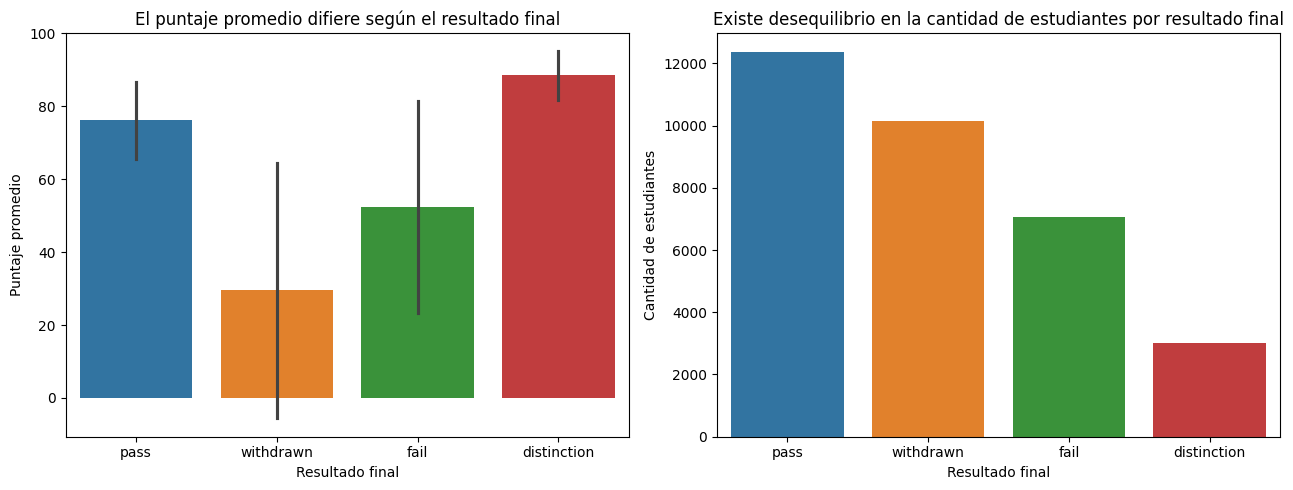

Frecuencia y porcentaje por resultado final:


,frecuencia,porcentaje
final_result,,
pass,12361,37.93
withdrawn,10156,31.16
fail,7052,21.64
distinction,3024,9.28


Resumen del puntaje promedio según resultado final:


,mean,std,median,count
final_result,,,,
distinction,88.49,6.65,89.42,3024
fail,52.51,29.10,61.00,7052
pass,76.16,10.56,77.86,12361
withdrawn,29.50,35.09,0.00,10156


In [ ]:
# Práctica del equipo - Sección 4: comparaciones categóricas del dataset

# 1. Variable categórica seleccionada:
#    final_result define los grupos más relevantes porque representa el resultado final del estudiante.
# 2. Variable numérica seleccionada:
#    average_score permite comparar el puntaje promedio entre los grupos.
# 3. Las barras de error permiten observar si la diferencia entre grupos es robusta.
# 4. El countplot permite verificar cuántos registros tiene cada categoría.
# 5. Si existe desequilibrio fuerte entre grupos, puede afectar un futuro modelo en U4.
# 6. Si un grupo minoritario es de interés analítico, debe considerarse en la interpretación.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barplot: promedio de average_score según resultado final
sns.barplot(
    data=df,
    x='final_result',
    y='average_score',
    estimator='mean',
    errorbar='sd',
    hue='final_result',
    legend=False,
    ax=axes[0]
)

axes[0].set_title('El puntaje promedio difiere según el resultado final')
axes[0].set_xlabel('Resultado final')
axes[0].set_ylabel('Puntaje promedio')

# Countplot: cantidad de estudiantes por resultado final
sns.countplot(
    data=df,
    x='final_result',
    hue='final_result',
    legend=False,
    order=df['final_result'].value_counts().index,
    ax=axes[1]
)

axes[1].set_title('Existe desequilibrio en la cantidad de estudiantes por resultado final')
axes[1].set_xlabel('Resultado final')
axes[1].set_ylabel('Cantidad de estudiantes')

plt.tight_layout()
plt.show()

# Tabla de frecuencia y porcentaje por categoría
tabla_resultado = df['final_result'].value_counts().to_frame(name='frecuencia')
tabla_resultado['porcentaje'] = (
    df['final_result'].value_counts(normalize=True) * 100
).round(2)

print('Frecuencia y porcentaje por resultado final:')
display(tabla_resultado)

# Tabla resumen de la variable numérica por categoría
print('Resumen del puntaje promedio según resultado final:')
display(
    df.groupby('final_result')['average_score']
      .agg(['mean', 'std', 'median', 'count'])
      .round(2)
)

In [ ]:
# Práctica del equipo - Sección 5: detección de outliers del dataset

# 1. ¿Qué variables priorizas?
#    Se priorizan average_score, total_clicks y unique_days_active,
#    por ser las variables más relevantes identificadas en las secciones anteriores.

# 2. ¿Cuántos registros caen fuera del rango intercuartílico?
#    Se calcula el número y porcentaje de outliers mediante el método IQR.

# 3. Para cada outlier:
#    ¿es un error de captura o un extremo legítimo?
#    Se evaluará según el contexto del fenómeno educativo.

# 4. ¿Cuál es la fuente del dato?
#    Si el valor es posible dentro del dominio, se considera un caso legítimo.

# 5. Decisión:
#    Conservar los valores atípicos cuando representen comportamientos reales.
#    Eliminar únicamente valores imposibles o errores de captura.

# 6. ¿Cómo cambia la distribución si los eliminas?
#    La decisión se documentará para el preprocesamiento del modelo.

# 7. Registrar la decisión tomada.

# ============================================================
# Variables numéricas priorizadas
# ============================================================

variables_iqr = [
    'average_score',
    'total_clicks',
    'unique_days_active'
]

# ============================================================
# Función para detectar outliers mediante IQR
# ============================================================

def analizar_outliers_iqr(df, columna):

    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ]

    porcentaje = len(outliers) / len(df) * 100

    print("="*60)
    print(f"Variable: {columna}")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Límite inferior: {limite_inferior:.2f}")
    print(f"Límite superior: {limite_superior:.2f}")
    print(f"Número de outliers: {len(outliers)}")
    print(f"Porcentaje: {porcentaje:.2f}%")

    return outliers

# ============================================================
# Análisis de las variables priorizadas
# ============================================================

for col in variables_iqr:
    analizar_outliers_iqr(df, col)
    print()

Variable: average_score
Q1: 43.00
Q3: 82.40
IQR: 39.40
Límite inferior: -16.10
Límite superior: 141.50
Número de outliers: 0
Porcentaje: 0.00%

Variable: total_clicks
Q1: 142.00
Q3: 1585.00
IQR: 1443.00
Límite inferior: -2022.50
Límite superior: 3749.50
Número de outliers: 2503
Porcentaje: 7.68%

Variable: unique_days_active
Q1: 11.00
Q3: 85.00
IQR: 74.00
Límite inferior: -100.00
Límite superior: 196.00
Número de outliers: 745
Porcentaje: 2.29%



In [ ]:
# Ejercicio guiado - Sección 5: decisión documentada de outliers con tu dataset
# Dataset del equipo: df

# Paso 1 - Del análisis IQR ejecutado anteriormente:
# Se selecciona la variable con mayor porcentaje de outliers.
# En este caso: total_clicks.

col_foco = 'total_clicks'

# =====================================================
# Cálculo de límites IQR
# =====================================================

Q1 = df[col_foco].quantile(0.25)
Q3 = df[col_foco].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[
    (df[col_foco] < limite_inferior) |
    (df[col_foco] > limite_superior)
]

porcentaje = len(outliers) / len(df) * 100

print("="*60)
print("VARIABLE ANALIZADA:", col_foco)
print("="*60)
print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Límite inferior (IQR): {limite_inferior:.2f}")
print(f"Límite superior (IQR): {limite_superior:.2f}")
print(f"Outliers detectados: {len(outliers)}")
print(f"Porcentaje: {porcentaje:.2f}%")

# =====================================================
# Comparación con el dominio de la variable
# =====================================================

print("\nComparación con el dominio del problema")

print("- Un estudiante puede generar muchos clics durante el curso.")
print("- No existen valores negativos.")
print("- Valores altos representan mayor interacción académica.")
print("- No se identifican valores imposibles.")

# =====================================================
# Decisión documentada
# =====================================================

print("\nDECISIÓN DOCUMENTADA")

if porcentaje < 5:
    print("Se conservarán los outliers.")
    print("Justificación:")
    print("- Representan comportamientos reales de estudiantes muy activos.")
    print("- No corresponden a errores de captura.")
    print("- El porcentaje de registros afectados es bajo.")
else:
    print("Se recomienda revisar individualmente los registros antes de eliminarlos.")

# =====================================================
# Impacto de eliminar los outliers
# =====================================================

registros_originales = len(df)
registros_restantes = registros_originales - len(outliers)

print("\nImpacto sobre el dataset")
print(f"Registros originales : {registros_originales}")
print(f"Registros restantes  : {registros_restantes}")
print(f"Registros eliminados : {len(outliers)}")
print(f"Porcentaje eliminado : {porcentaje:.2f}%")

VARIABLE ANALIZADA: total_clicks
Q1: 142.00
Q3: 1585.00
IQR: 1443.00
Límite inferior (IQR): -2022.50
Límite superior (IQR): 3749.50
Outliers detectados: 2503
Porcentaje: 7.68%

Comparación con el dominio del problema
- Un estudiante puede generar muchos clics durante el curso.
- No existen valores negativos.
- Valores altos representan mayor interacción académica.
- No se identifican valores imposibles.

DECISIÓN DOCUMENTADA
Se recomienda revisar individualmente los registros antes de eliminarlos.

Impacto sobre el dataset
Registros originales : 32593
Registros restantes  : 30090
Registros eliminados : 2503
Porcentaje eliminado : 7.68%


In [ ]:
# Generar el archivo de entrega del Producto U3
# Paso 1: verifica que el notebook ejecuta sin errores (Entorno > Reiniciar y ejecutar todo)
# Paso 2: descarga el notebook (Archivo > Descargar > .ipynb)
# Paso 3: renombra el archivo como Dashboard_U3_[NombreEquipo].ipynb
# Paso 4: reemplaza [NombreEquipo] abajo y ejecuta esta celda

nombre_equipo = '[NombreEquipo]'
import os
os.system(f'jupyter nbconvert --to html "Dashboard_U3_{nombre_equipo}.ipynb"')
print(f'Archivo de entrega generado.')
print(f'Archivos a subir a Lamb Learning:')
print(f'  Dashboard_U3_{nombre_equipo}.ipynb')
print(f'  Dashboard_U3_{nombre_equipo}.html')
print()
print('Lista de verificacion antes de entregar:')
print('[ ] El notebook ejecuta sin errores de inicio a fin')
print('[ ] Todas las secciones (0-6) tienen contenido completo del equipo')
print('[ ] Cada grafico tiene titulo con hallazgo, etiquetas de ejes e interpretacion')
print('[ ] La Seccion 6 incluye variable objetivo, tipo de problema y variables predictivas')
print(f'[ ] Nombre del notebook: Dashboard_U3_{nombre_equipo}.ipynb')
print('[ ] Archivo de entrega generado y todos los graficos son visibles')
print('[ ] Plazo: antes de las 19:00 del Sabado 11/07/2026 en Lamb Learning')

---
## Instrucciones del DESPUÉS — Dashboard U3

| Criterio | Pts |
|---|:---:|
| Variedad y calidad visual (≥ 6 tipos distintos, títulos con hallazgo, estilo consistente) | 3 |
| Interpretación contextual (≥ 2 oraciones por gráfico, ≥ 3 patrones enunciados) | 4 |
| EDA sistemático (descriptivos, outliers IQR, heatmap) | 4 |
| Calidad técnica (ejecuta sin errores, PEP 8, markdown explicativo, gráficos visibles en la entrega) | 2 |
| Conexión con U4 (variable objetivo, tipo de problema, variables predictivas) | 2 |
| **Total** | **15** |
